            timestamp  rain_pixels  rain_fraction       mean       std  \
0 2011-01-17 15:36:00          184       0.031293  31.663322  8.129971   
1 2011-01-17 15:44:00          207       0.035204  29.805325  7.576298   
2 2011-01-17 15:46:00          213       0.036224  29.541319  7.312479   
3 2011-01-17 15:48:00          197       0.033503  29.265385  7.915115   
4 2011-01-17 15:50:00          192       0.032653  29.176849  7.859232   

   maximum       volume        p50   p90        p95   p99  hour  
0     45.0  5826.051270  30.000000  40.0  45.000000  45.0    15  
1     45.0  6169.702148  30.000000  40.0  43.898239  45.0    15  
2     45.0  6292.300781  30.000000  40.0  45.000000  45.0    15  
3     45.0  5765.280762  30.000000  40.0  44.441284  45.0    15  
4     45.0  5601.955078  28.380985  40.0  43.221180  45.0    15  
      mean_reflectivity  rainfall_volume  rain_fraction    maximum       std
hour                                                                        
0    

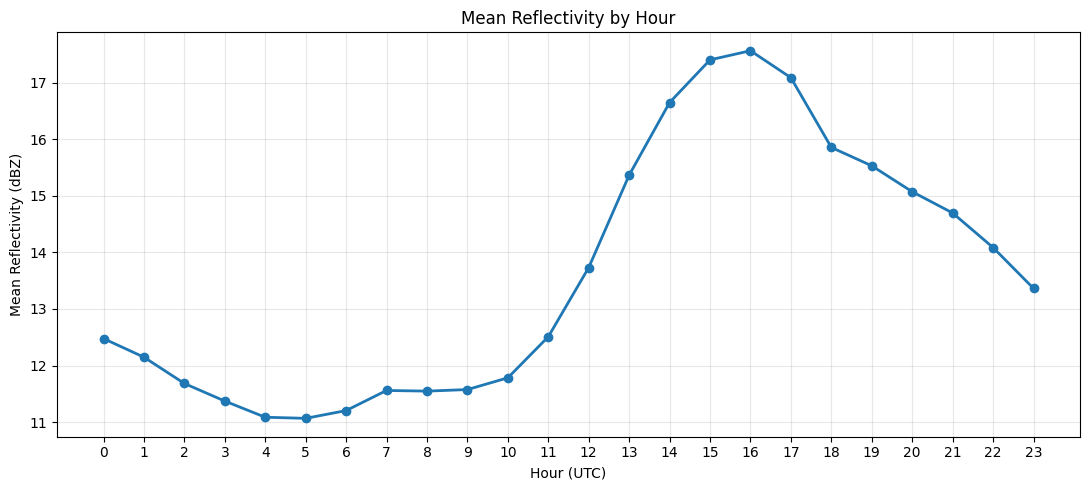

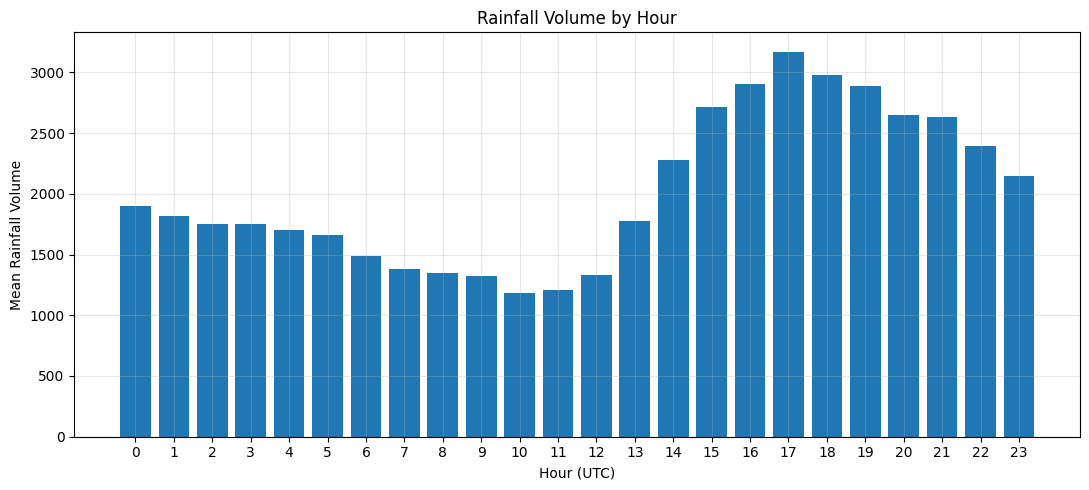

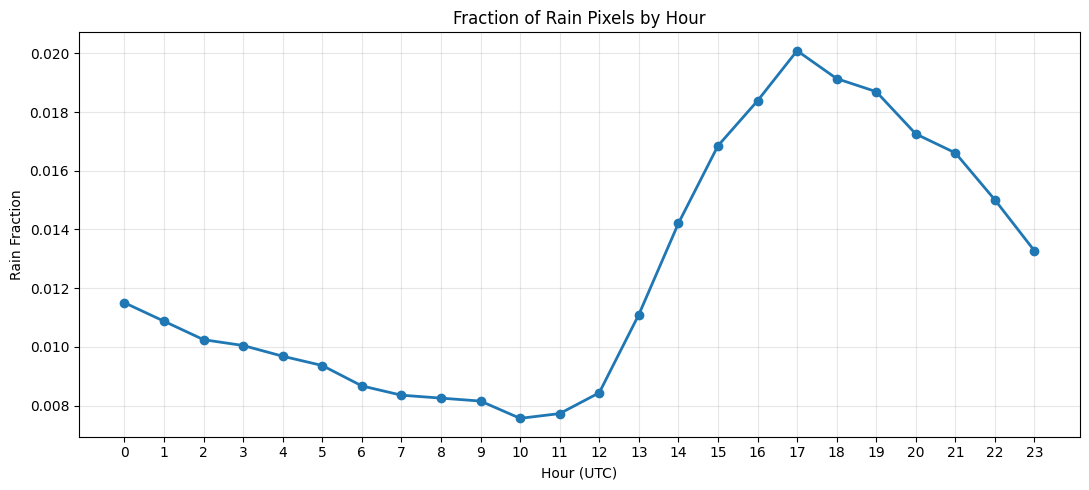

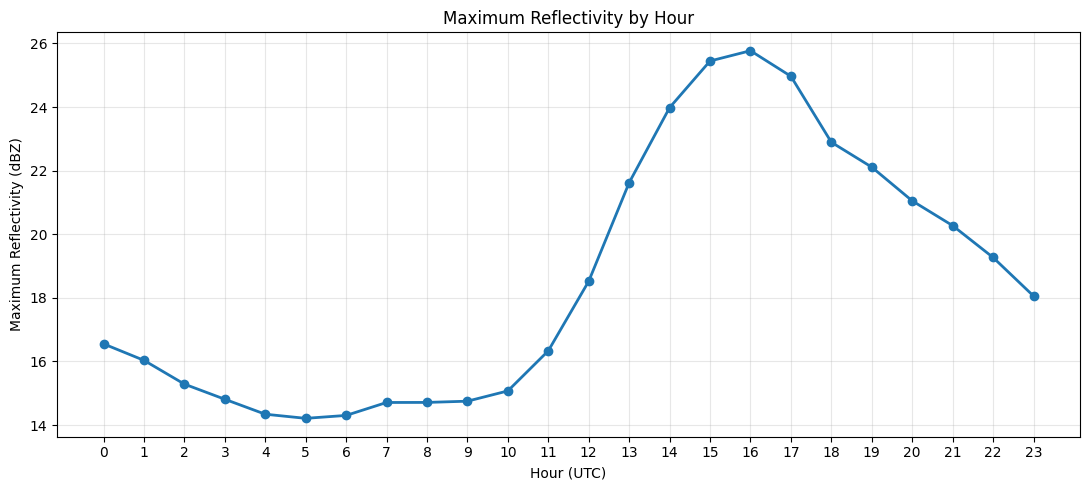

<Figure size 1400x600 with 0 Axes>

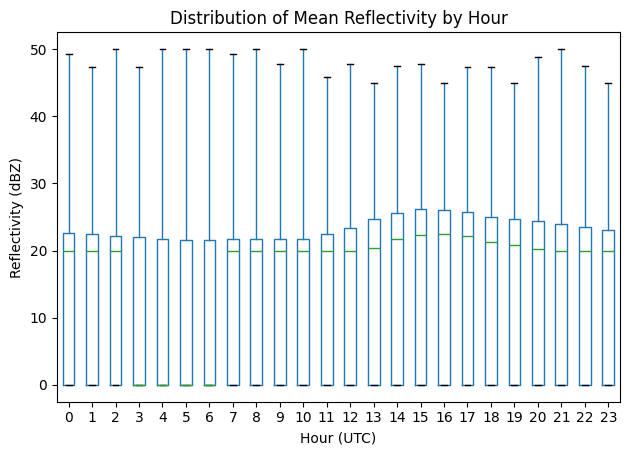


Five rainiest hours (mean rainfall volume):

      mean_reflectivity  rainfall_volume  rain_fraction    maximum       std
hour                                                                        
17            17.090167      3170.449944       0.020088  24.966391  3.206126
18            15.857162      2978.116959       0.019138  22.892765  2.814594
16            17.567479      2906.696539       0.018381  25.770166  3.430856
19            15.532069      2888.475911       0.018694  22.109608  2.591097
15            17.405899      2714.400677       0.016849  25.446424  3.394549

Five highest rain coverage hours:

      mean_reflectivity  rainfall_volume  rain_fraction    maximum       std
hour                                                                        
17            17.090167      3170.449944       0.020088  24.966391  3.206126
18            15.857162      2978.116959       0.019138  22.892765  2.814594
19            15.532069      2888.475911       0.018694  22.109608  2.5

In [2]:
# =============================================================================
# Notebook 03
# Diurnal Rainfall Climatology
#
# This notebook analyses the historical daily cycle of precipitation
# observed by the radar.
#
# Outputs
#
# figure01_hourly_mean.png
# figure02_hourly_volume.png
# figure03_hourly_rain_fraction.png
# figure04_hourly_maximum.png
# figure05_hourly_boxplot.png
#
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# =============================================================================
# Configuration
# =============================================================================

STATISTICS_DIR = Path("datasets/radar_statistics")

FIGURES = Path("figures/notebook03")

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# Load statistics
# =============================================================================

df = pd.read_parquet(
    STATISTICS_DIR / "summary.parquet"
)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df.timestamp.dt.hour

print(df.head())

# =============================================================================
# Hourly climatology
# =============================================================================

hourly = (
    df.groupby("hour")
      .agg(
          mean_reflectivity=("mean", "mean"),
          rainfall_volume=("volume", "mean"),
          rain_fraction=("rain_fraction", "mean"),
          maximum=("maximum", "mean"),
          std=("std", "mean"),
      )
)

print(hourly)

# =============================================================================
# Figure 1
# Mean Reflectivity
# =============================================================================

plt.figure(figsize=(11,5))

plt.plot(
    hourly.index,
    hourly.mean_reflectivity,
    marker="o",
    linewidth=2
)

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.xlabel("Hour (UTC)")

plt.ylabel("Mean Reflectivity (dBZ)")

plt.title("Mean Reflectivity by Hour")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure01_hourly_mean.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 2
# Rainfall Volume
# =============================================================================

plt.figure(figsize=(11,5))

plt.bar(
    hourly.index,
    hourly.rainfall_volume
)

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.xlabel("Hour (UTC)")

plt.ylabel("Mean Rainfall Volume")

plt.title("Rainfall Volume by Hour")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure02_hourly_volume.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 3
# Rain Fraction
# =============================================================================

plt.figure(figsize=(11,5))

plt.plot(
    hourly.index,
    hourly.rain_fraction,
    marker="o",
    linewidth=2
)

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.xlabel("Hour (UTC)")

plt.ylabel("Rain Fraction")

plt.title("Fraction of Rain Pixels by Hour")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure03_hourly_rain_fraction.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 4
# Maximum Reflectivity
# =============================================================================

plt.figure(figsize=(11,5))

plt.plot(
    hourly.index,
    hourly.maximum,
    marker="o",
    linewidth=2
)

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.xlabel("Hour (UTC)")

plt.ylabel("Maximum Reflectivity (dBZ)")

plt.title("Maximum Reflectivity by Hour")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure04_hourly_maximum.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 5
# Hourly distribution
# =============================================================================

plt.figure(figsize=(14,6))

df.boxplot(
    column="mean",
    by="hour",
    grid=False
)

plt.title("Distribution of Mean Reflectivity by Hour")

plt.suptitle("")

plt.xlabel("Hour (UTC)")

plt.ylabel("Reflectivity (dBZ)")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure05_hourly_boxplot.png",
    dpi=300
)

plt.show()

# =============================================================================
# Peak Hours
# =============================================================================

print("\nFive rainiest hours (mean rainfall volume):\n")

print(
    hourly
    .sort_values(
        "rainfall_volume",
        ascending=False
    )
    .head(5)
)

print("\nFive highest rain coverage hours:\n")

print(
    hourly
    .sort_values(
        "rain_fraction",
        ascending=False
    )
    .head(5)
)

print("\nFive highest maximum reflectivity hours:\n")

print(
    hourly
    .sort_values(
        "maximum",
        ascending=False
    )
    .head(5)
)

# =============================================================================
# Save results
# =============================================================================

hourly.to_csv(
    FIGURES/"hourly_climatology.csv"
)

print("\nHourly climatology saved.")

print("Notebook completed successfully.")